# MidiTranslatorEncDec — encoder-decoder seq2seq2 translator, model validation

Loads `configs/midi-translator-seq2seq2-encdec.yaml` and validates `MidiTranslatorEncDec` /
`MidiTranslatorEncDecLoss` against the `Seq2Seq2` batch in its **split** form.

This is the paired experiment to `midiTranslator_validation.ipynb`. Both models read the same feeder,
the same corpus, the same crops, and are supervised on the same labels; the only difference is where
the source goes:

| | source | target |
|---|---|---|
| `MidiTranslator` | a prefix in one causal stack | the rest of that same stack |
| `MidiTranslatorEncDec` | a **bidirectional encoder** | a causal decoder reading it by **cross-attention** |

`pack: 'split'` is what supplies the shape. It cuts the *same* assembled sequence at its own recorded
`<sep>`, hands `<sep>` to the decoder as its start token, and shifts the target into
`(decoder_input_ids, labels)`:

```
source_ids         <bos>? source...                 (no <sep> — it went to the decoder)
decoder_input_ids  <sep> ++ target[:-1]
labels             target
```

So the shift happens in the **collate**, not in the loss — and that is the first thing this notebook
checks, in two independent ways. Because the two architectures are meant to be compared, an equally
important check is **§2b: the supervised label set is bit-identical to the flat form's**. Without that,
a loss difference between the two runs could just as easily be a difference in what each was asked to
predict.

The other thing worth watching here is the **mask asymmetry**, which is not symmetric between the two
stacks and cannot be: the encoder attends **fully** (bidirectionally) and so genuinely needs its
key-padding mask, while the decoder's self-attention takes the causal mask *alone*. §4a recovers all
three masks from the model's own outputs rather than trusting the ones we believe we passed.

Sections:
1. Load the config, a batch, and a small CPU model
2. Batch geometry — the eight tensors of the split form
   (2b. **label-set parity** with the flat form — the load-bearing check)
   (2c. `pos_style`: one position axis, cut in two)
3. The shift, checked on a hand-built row where every position is identifiable
4. The three masks — full encoder, causal decoder, source-masked cross
   (4a. all three recovered by perturbation)
5. Padding invariance
6. Loss, metrics, `stat()` folding, and what is inherited from `MidiTranslatorLoss`
7. Overfit one batch
8. Free-run generation — encode once, then step the decoder
9. Cross-attention alignment, the thing only this architecture has

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as tud

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel
from starry.utils.weightedValue import WeightedValue
from starry.midi.data.seq2seq2 import Seq2Seq2

CONFIG = str(REPO_ROOT / 'configs' / 'midi-translator-seq2seq2-encdec.yaml')
DATA_DIR = os.environ['DATA_DIR']
torch.manual_seed(0)

# Okabe-Ito, consistent with the other notebooks in this directory. C_SRC is the encoder/source half
# throughout, C_TGT the decoder/target half.
C_SRC, C_TGT = '#0072B2', '#D55E00'

## 1. Load the config, a batch, and a small CPU model

The data block is read exactly as the trainer reads it; only `batch_size` and the model size are
shrunk so this runs on CPU in seconds. `random_crop=False` on the val arm means a re-run inspects the
same sample.

`loadModel(config['model'], postfix='Loss')` is the trainer's own call — the config says
`type: MidiTranslatorEncDec` and what comes back is `MidiTranslatorEncDecLoss`. Note what that wrapper
*is*: a subclass of `MidiTranslatorLoss` overriding exactly three hooks (`DEDUCER`, `_logits`,
`_shift`). Everything about the vocabulary and the metrics is inherited, which is what makes the two
runs' `loss` and `error/*` panels measure the same quantities. §6 checks that inheritance directly.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)

print('pairing   :', config['data.args.source_dir'], '->', config['data.args.target_dir'])
print('pack      :', config['data.args.pack'], '| pos_style:', config['data.args.pos_style'])
print('mark_mode :', config['data.args.mark_mode'], '| line_range:', config['data.args.line_range'])
print('data root :', Path(DATA_DIR) / config['data.root'])
print('model     :', config['model.type'],
      '| encoder %d / decoder %d layers' % (config['model.args.n_layer_encoder'],
                                            config['model.args.n_layer_decoder']))

train_loader, val_loader = loadDataset(config, data_dir=DATA_DIR, device='cpu')
train, val = train_loader.dataset, val_loader.dataset
print('samples   : train', len(train), '| val', len(val))

BS = 3
loader = tud.DataLoader(val, batch_size=BS, collate_fn=val.collateBatch)
batch = next(iter(loader))

# A small CPU model: same architecture, fewer dims. The production size (d_model 512, e4d4 = 38.4M
# params) is in the config.
small = dict(config['model.args'])
small.update(d_model=128, n_layer_encoder=2, n_layer_decoder=2, n_head=4)
model = loadModel({'type': config['model.type'], 'args': small},
    postfix='Loss', imports=config['imports'])
model.eval()   # dropout is 0.1 in the config; every comparison below would otherwise be noise
print('\nloadModel ->', type(model).__name__, '| deducer:', type(model.deducer).__name__)
print('params    : %.2fM (small) | vocab %d' % (
    sum(p.numel() for p in model.parameters()) / 1e6, model.deducer.vocab_size))
print('MRO       :', ' <- '.join(c.__name__ for c in type(model).__mro__[:3]))
print('sep_id    :', model.deducer.sep_id, '(the decoder start token, taken from the pinned vocab)')

pairing   : midi-seq2-irregular -> midi-seq2-score
pack      : split | pos_style: absolute
mark_mode : tick | line_range: [20, 256]
data root : /home/camus/data/midi/test202608
model     : MidiTranslatorEncDec | encoder 4 / decoder 4 layers
samples   : train 90 | val 9

loadModel -> MidiTranslatorEncDecLoss | deducer: MidiTranslatorEncDec
params    : 1.33M (small) | vocab 582
MRO       : MidiTranslatorEncDecLoss <- MidiTranslatorLoss <- Module
sep_id    : 5 (the decoder start token, taken from the pinned vocab)


## 2. Batch geometry

Eight tensors instead of the flat form's five, in two groups. The invariants that make the loss
well-defined are correspondingly different: there is no `sep_index` because the boundary is no longer
*inside* a sequence — it became the split itself, and `<sep>` moved to the head of the decoder input.

What has to hold:

- `source_ids` carries **no** `<sep>` at all. A copy on the encoder side would make the boundary
  ambiguous to anything reading the batch back.
- `decoder_input_ids[:, 0]` is `<sep>` in every row, and appears exactly once.
- `labels` is `decoder_input_ids` shifted left by one, over each row's real length.
- `target_mask` selects the labels, and is a subset of `decoder_masks` (never supervise padding).

In [3]:
src, src_mask, src_pos = batch['source_ids'], batch['source_masks'], batch['source_position_ids']
dec, dec_mask, dec_pos = batch['decoder_input_ids'], batch['decoder_masks'], batch['decoder_position_ids']
labels, tmask = batch['labels'], batch['target_mask']
tok = val.tokenizer
print('shapes:', {k: tuple(v.shape) for k, v in batch.items()})
print()

print('%-5s %8s %8s %8s  %s' % ('row', 'source', 'decoder', 'target', 'last label'))
for r in range(len(src)):
    print('%-5d %8d %8d %8d  %s' % (r, int(src_mask[r].sum()), int(dec_mask[r].sum()),
        int(tmask[r].sum()), tok.tokens[int(labels[r, int(tmask[r].sum()) - 1])]))

# labels == decoder_input shifted left, over each row's real length. Checked row-wise because the two
# tensors share a width but each row's real length differs.
shift_ok = all(
    torch.equal(labels[r, :int(dec_mask[r].sum()) - 1], dec[r, 1:int(dec_mask[r].sum())])
    for r in range(len(src)))

checks = [
    ('no <sep> in source_ids', int((src == tok.sep_id).sum()) == 0),
    ('decoder starts with <sep>', bool((dec[:, 0] == tok.sep_id).all())),
    ('exactly one <sep> per decoder row', bool((dec == tok.sep_id).sum(dim=1).eq(1).all())),
    ('labels == decoder_input shifted left', shift_ok),
    ('target_mask subset of decoder_masks', bool(((tmask == 1) <= (dec_mask == 1)).all())),
    ('target_mask starts at 0 (no jitter)', all(int(tmask[r].nonzero()[0]) == 0 for r in range(len(src)))),
    ('target_mask covers the whole real row', all(
        int(tmask[r].sum()) == int(dec_mask[r].sum()) for r in range(len(src)))),
    ('labels end with <eos>', all(
        int(labels[r, int(tmask[r].sum()) - 1]) == tok.eos_id for r in range(len(src)))),
    ('no <eos> in source_ids', int((src == tok.eos_id).sum()) == 0),
    ('no <unknown> anywhere', int((src == tok.unknown_id).sum()) + int((labels == tok.unknown_id).sum()) == 0),
]
print()
for name, ok in checks:
    print(('  OK   ' if ok else '  FAIL ') + name)
assert all(ok for _, ok in checks)

shapes: {'source_ids': (3, 629), 'source_masks': (3, 629), 'source_position_ids': (3, 629), 'decoder_input_ids': (3, 244), 'decoder_masks': (3, 244), 'decoder_position_ids': (3, 244), 'labels': (3, 244), 'target_mask': (3, 244)}

row     source  decoder   target  last label
0           93       48       48  <eos>
1          358      222      222  <eos>
2          629      244      244  <eos>

  OK   no <sep> in source_ids
  OK   decoder starts with <sep>
  OK   exactly one <sep> per decoder row
  OK   labels == decoder_input shifted left
  OK   target_mask subset of decoder_masks
  OK   target_mask starts at 0 (no jitter)
  OK   target_mask covers the whole real row
  OK   labels end with <eos>
  OK   no <eos> in source_ids
  OK   no <unknown> anywhere


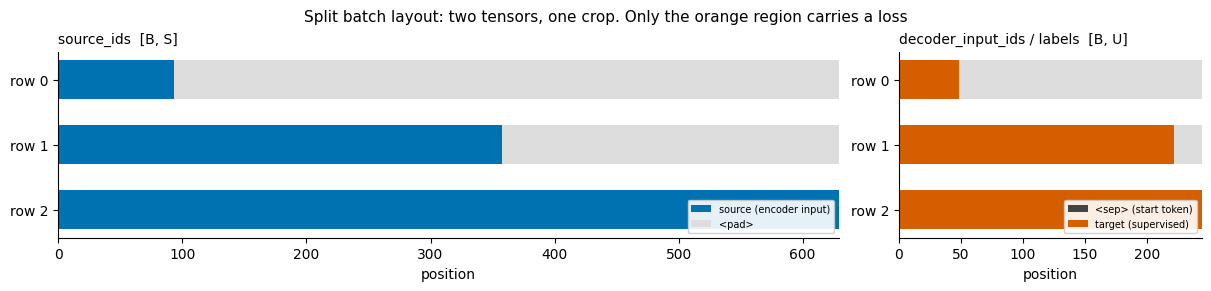

S = 629 (widest source), U = 244 (widest decoder). In the flat form this same batch is one
tensor of width S + 1 + U = 874, so the split form is not smaller -- it is differently shaped.


In [4]:
# The two tensors drawn to scale, side by side. Compare with the flat notebook's single-bar layout:
# the same crop, the same tokens, redistributed across two tensors of independent width.
fig, axes = plt.subplots(1, 2, figsize=(12, 1.3 + 0.5 * len(src)), layout='constrained',
                         gridspec_kw={'width_ratios': [src.shape[1], dec.shape[1]]})
for r in range(len(src)):
    ns = int(src_mask[r].sum())
    axes[0].barh(r, ns, color=C_SRC, height=0.6, label='source (encoder input)' if r == 0 else None)
    axes[0].barh(r, src.shape[1] - ns, left=ns, color='#dddddd', height=0.6,
                 label='<pad>' if r == 0 else None)
    nd = int(dec_mask[r].sum())
    axes[1].barh(r, 1, color='#444444', height=0.6, label='<sep> (start token)' if r == 0 else None)
    axes[1].barh(r, nd - 1, left=1, color=C_TGT, height=0.6,
                 label='target (supervised)' if r == 0 else None)
    axes[1].barh(r, dec.shape[1] - nd, left=nd, color='#dddddd', height=0.6)
for ax, title in ((axes[0], 'source_ids  [B, S]'), (axes[1], 'decoder_input_ids / labels  [B, U]')):
    ax.set_yticks(range(len(src)))
    ax.set_yticklabels([f'row {r}' for r in range(len(src))])
    ax.set_xlabel('position')
    ax.set_title(title, fontsize=10, loc='left')
    ax.invert_yaxis()
    ax.legend(loc='lower right', fontsize=7, framealpha=0.9)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
fig.suptitle('Split batch layout: two tensors, one crop. Only the orange region carries a loss', fontsize=11)
plt.show()

print('S = %d (widest source), U = %d (widest decoder). In the flat form this same batch is one'
      % (src.shape[1], dec.shape[1]))
print('tensor of width S + 1 + U = %d, so the split form is not smaller -- it is differently shaped.'
      % (src.shape[1] + 1 + dec.shape[1]))

## 2b. Label-set parity with the flat form

**The load-bearing check of this notebook.** The whole point of the split form is to let this
architecture be compared against the decoder-only one on the same corpus, and that comparison is only
meaningful if both are asked to predict the same thing.

So: build two feeders differing *only* in `pack`, with `random_crop=False` so each crop is a function
of its index and both see the same crops. Then run each form's own loss `_shift` over its own batch and
compare what comes out. Comparing the tensors the **models actually see** rather than re-deriving them
here means a bug in either `_shift` fails this cell.

Three ways it could pass by accident, each ruled out separately below: same count but different
tokens; same multiset but permuted across rows; and same labels but a different *number of rows*
contributing them.

It is also checked under `start_jitter`, where the feeder deliberately withholds the target's first bar
because the source is missing its head. That head must be masked in both forms and land on the same
tokens — an off-by-one there would train the split form on a token the flat form withholds.

In [5]:
from starry.midi.models.midiTranslator import MidiTranslatorLoss

DATA_ROOT = str(Path(DATA_DIR) / config['data.root'])

def pack_feeder(pack, **over):
    '''Val-split feeder differing only in `pack`. random_crop=False makes every crop a function of its
    index, so the two forms see the SAME crops and their labels are directly comparable.'''
    args = dict(config['data.args']); args.update(pack=pack, random_crop=False, **over)
    return Seq2Seq2.load(DATA_ROOT, args, splits=config['data.splits'],
        args_variant=config['data.args_variant'])[1]

flat_ds, split_ds = pack_feeder('flat'), pack_feeder('split')
idx = list(range(BS))
flat_b = flat_ds.collateBatch([flat_ds[i] for i in idx])
split_b = split_ds.collateBatch([split_ds[i] for i in idx])

# A flat-form loss wrapper, only for its _shift. Logits enter _shift for their SHAPE, so zeros do.
flat_model = loadModel({'type': 'MidiTranslator', 'args': {**small, 'backbone': 'llama', 'n_layer': 2}},
    postfix='Loss', imports=config['imports'])
V = model.deducer.vocab_size
_, flat_labels = flat_model._shift(flat_b, torch.zeros(*flat_b['input_ids'].shape, V))
_, split_labels = model._shift(split_b, torch.zeros(*split_b['labels'].shape, V))

flat_counts = flat_b['target_mask'][:, 1:].sum(dim=1).tolist()
split_counts = split_b['target_mask'].sum(dim=1).tolist()

print('flat  supervised: %d tokens over %d rows %s' % (
    flat_labels.numel(), len(flat_counts), flat_counts))
print('split supervised: %d tokens over %d rows %s' % (
    split_labels.numel(), len(split_counts), split_counts))
print()
print('same total count          :', flat_labels.shape == split_labels.shape)
print('same labels, same ORDER   :', bool((flat_labels == split_labels).all()))
print('same per-row counts       :', flat_counts == split_counts)
print('   (rules out a same-multiset-different-rows match)')
assert flat_labels.shape == split_labels.shape
assert bool((flat_labels == split_labels).all())
assert flat_counts == split_counts

# Under start_jitter the first bar of the target goes unsupervised. Both forms must withhold the SAME
# tokens, so this is the same comparison with the augmentation on.
jit = dict(mark_mode='tick', start_jitter=8.0, line_range=[40, 96])
fj, sj = pack_feeder('flat', **jit), pack_feeder('split', **jit)
jidx = list(range(min(6, len(sj))))
fjb, sjb = fj.collateBatch([fj[i] for i in jidx]), sj.collateBatch([sj[i] for i in jidx])
skips = [sj[i][3] for i in jidx]
_, fjl = flat_model._shift(fjb, torch.zeros(*fjb['input_ids'].shape, V))
_, sjl = model._shift(sjb, torch.zeros(*sjb['labels'].shape, V))
print('\nwith start_jitter=8.0: skips %s (%d nonzero)' % (skips, sum(1 for s in skips if s)))
print('same labels under jitter  :', fjl.shape == sjl.shape and bool((fjl == sjl).all()),
      '(%d tokens)' % sjl.numel())
print('skipped head masked, not dropped:', all(
    int(sjb['target_mask'][r, :s].sum()) == 0 for r, s in enumerate(skips) if s))
assert fjl.shape == sjl.shape and bool((fjl == sjl).all())

flat  supervised: 514 tokens over 3 rows [48, 222, 244]
split supervised: 514 tokens over 3 rows [48, 222, 244]

same total count          : True
same labels, same ORDER   : True
same per-row counts       : True
   (rules out a same-multiset-different-rows match)

with start_jitter=8.0: skips [0, 49, 25, 37, 10, 0] (4 nonzero)
same labels under jitter  : True (331 tokens)
skipped head masked, not dropped: True


## 2c. `pos_style` — one position axis, cut in two

`pos_style` works exactly as in the flat form (see `midiTranslator_validation.ipynb` §2b for what the
three conventions mean and why `absolute` is built the way it is). What the split form adds is a
question of its own: the two halves are cut out of **one** position run, so concatenating them back
must reproduce the flat form's positions over the same span. If it did not, the halves would sit on
axes that disagree, and under `absolute` — where the gap between them is the crop's own geometry — that
would silently destroy the information the style exists to carry.

`<sep>` leads the decoder and its position leads the decoder's run. So under `sep` and `absolute` the
decoder's first position is `-1` by construction, and the target's own positions follow from there.

The pad tail of *both* tensors continues its row's run rather than taking a constant fill, for the same
reason as the flat form: RoPE rotates every position before the attention mask drops it, so a constant
(0 especially, which every style uses for a real position) breaks the arithmetic run.

The cell below ends with a measurement worth stating plainly: because RoPE reads only relative
distance, `sep` is a **uniform shift** of `flat` and therefore the same model input, while `absolute` is
not a shift — under `mark_mode: 'tick'` its positions are tick values, so two tokens on the same tick
share one, and that reaches the decoder.

In [6]:
print('%-9s %-46s %s' % ('style', 'source half', 'decoder half (<sep> first)'))
for style in ('flat', 'sep', 'absolute'):
    ds = pack_feeder('split', pos_style=style)
    fds = pack_feeder('flat', pos_style=style)
    b = ds.collateBatch([ds[i] for i in idx])
    # NOTE: the items must come from the same-pos_style feeder — positions are baked into the ITEM,
    # collateBatch only pads them, so reusing flat_ds's items here would compare two styles.
    fb = fds.collateBatch([fds[i] for i in idx])
    ns, nd = int(b['source_masks'][0].sum()), int(b['decoder_masks'][0].sum())
    sp, dp = b['source_position_ids'][0], b['decoder_position_ids'][0]
    print('%-9s [%8d .. %8d]  (%4d real)          [%7d .. %7d]'
          % (style, sp[0], sp[ns - 1], ns, dp[0], dp[nd - 1]))

    # The two halves must rejoin the flat form's axis over each row's true span.
    rejoin = all(torch.equal(
        torch.cat([b['source_position_ids'][r, :int(b['source_masks'][r].sum())],
                   b['decoder_position_ids'][r, :int(b['decoder_masks'][r].sum())]]),
        fb['position_ids'][r, :int(b['source_masks'][r].sum()) + int(b['decoder_masks'][r].sum())])
        for r in range(len(b['source_ids'])))
    # Pad tails continue, in both tensors.
    cont = True
    for key, mkey in (('source_position_ids', 'source_masks'), ('decoder_position_ids', 'decoder_masks')):
        for r in range(len(b['source_ids'])):
            n = int(b[mkey][r].sum()); tail = b[key][r, n:]
            if len(tail):
                cont = cont and int(b[key][r, n] - b[key][r, n - 1]) == 1 and bool((tail.diff() == 1).all())
    print('%-9s halves rejoin the flat axis: %-5s | pad tails continue: %-5s | <sep> at %d'
          % ('', rejoin, cont, dp[0]))
    assert rejoin and cont
    if style in ('sep', 'absolute'):
        assert int(dp[0]) == -1, '<sep> must anchor the decoder at -1 under %s' % style

# What pos_style actually changes here. RoPE reads relative distance only, so a style that is a
# uniform SHIFT of the whole axis changes nothing — and `sep` is exactly that relative to `flat`.
# `absolute` is not a shift: under mark_mode 'tick' its positions are tick values, so two tokens on the
# same tick share a position, and repeats are not reachable by shifting consecutive integers.
print()
out = {}
for style in ('flat', 'sep', 'absolute'):
    ds = pack_feeder('split', pos_style=style)
    b = ds.collateBatch([ds[i] for i in idx])
    with torch.no_grad():
        out[style] = (
            model.deducer.encode(b['source_ids'], b['source_masks'], b['source_position_ids']),
            model.deducer(b['source_ids'], b['decoder_input_ids'], b['source_masks'],
                b['source_position_ids'], b['decoder_position_ids']))
    reps = sum(int((b[k][r, :int(b[m][r].sum())].diff() == 0).sum())
        for k, m in (('source_position_ids', 'source_masks'),
                     ('decoder_position_ids', 'decoder_masks')) for r in range(len(b['source_ids'])))
    print('%-9s repeated positions across the batch: %d' % (style, reps))

print()
for style in ('sep', 'absolute'):
    print('flat vs %-9s  encoder max|delta| %.3e   logits max|delta| %.3e' % (style,
        (out['flat'][0] - out[style][0]).abs().max().item(),
        (out['flat'][1] - out[style][1]).abs().max().item()))
d_sep = (out['flat'][1] - out['sep'][1]).abs().max().item()
d_abs = (out['flat'][1] - out['absolute'][1]).abs().max().item()
assert d_sep < 1e-4, 'sep is a uniform shift of flat; RoPE must not notice'
assert d_abs > 1e-3, 'absolute carries tick repeats and must reach the model'
print()
print('So `sep` and `flat` are the same model input in this architecture, and `absolute` is not — the')
print('difference lands in the DECODER (its positions repeat), not the encoder (whose crop is')
print('contiguous in ticks either way). Contrast the flat form, where the gap between the halves also')
print('changes source-to-target distances inside one causal stack.')
print('\nconfig uses pos_style:', config['data.args.pos_style'])

style     source half                                    decoder half (<sep> first)
flat      [       0 ..       92]  (  93 real)          [     93 ..     140]
          halves rejoin the flat axis: True  | pad tails continue: True  | <sep> at 93
sep       [     -94 ..       -2]  (  93 real)          [     -1 ..      46]
          halves rejoin the flat axis: True  | pad tails continue: True  | <sep> at -1
absolute  [  -17285 ..   -17193]  (  93 real)          [     -1 ..      45]
          halves rejoin the flat axis: True  | pad tails continue: True  | <sep> at -1

flat      repeated positions across the batch: 0
sep       repeated positions across the batch: 0
absolute  repeated positions across the batch: 2

flat vs sep        encoder max|delta| 2.265e-06   logits max|delta| 6.557e-07
flat vs absolute   encoder max|delta| 5.519e-05   logits max|delta| 6.535e-02

So `sep` and `flat` are the same model input in this architecture, and `absolute` is not — the
difference lands in the DE

## 3. The shift, on a row where every position is identifiable

In the flat form the shift lives in `_shift`. Here it lives in the **collate**, and `_shift` does no
shifting at all — it only selects and flattens. That moves the risk rather than removing it, so it is
checked the same way: with a hand-built row and synthetic logits whose argmax at position `j` is the
unique value `j * 100`, making the logits row used for each label readable off the returned tensor.

Decoder row: `[<sep>, 20, 21]` with labels `[20, 21, <eos>]`.

What has to come out:
- labels `[20, 21, <eos>]` — `<eos>` included, it is a supervised stop signal
- logits rows `[0, 1, 2]` — i.e. **row `j` predicts label `j`, with no offset**

The second point is the contrast with the flat form, where the same three labels are predicted from
rows `[2, 3, 4]`. Both are correct; they are the same geometry expressed at different points in the
pipeline. What matters is that exactly one of the two applies a shift — apply it in both and the model
predicts the token it was just handed, which still trains and still shows a falling loss.

In [7]:
SEP, EOS, PAD, BOS = tok.sep_id, tok.eos_id, tok.pad_id, tok.bos_id
probe = dict(
    decoder_input_ids=torch.tensor([[SEP, 20, 21, PAD]]),
    labels=torch.tensor([[20, 21, EOS, PAD]]),
    target_mask=torch.tensor([[1, 1, 1, 0]]),
)
U = probe['labels'].shape[1]

# Synthetic logits: argmax at decoder position j is j * 100, so a returned row identifies its origin.
fake = torch.full((1, U, model.deducer.vocab_size), -10.0)
for t in range(U):
    fake[0, t, t * 100] = 10.0

pred, lab = model._shift(probe, fake)
used_rows = (pred.argmax(dim=-1) // 100).tolist()

print('labels    :', lab.tolist(), '  (expect [20, 21, %d] — target tokens incl. <eos>)' % EOS)
print('logits row:', used_rows, '  (expect [0, 1, 2] — NO offset; the collate already shifted)')
print()
print('%-4s %-12s %-12s %-12s %s' % ('j', 'decoder in', 'label', 'role', 'predicted from'))
for t in range(U):
    role = 'SUPERVISED' if probe['target_mask'][0, t] == 1 else 'padding'
    frm = ('row %d' % t) if probe['target_mask'][0, t] == 1 else '-'
    print('%-4d %-12s %-12s %-12s %s' % (t, tok.tokens[int(probe['decoder_input_ids'][0, t])],
        tok.tokens[int(probe['labels'][0, t])], role, frm))

assert lab.tolist() == [20, 21, EOS]
assert used_rows == [0, 1, 2], used_rows
print('\nshift geometry OK — and note the contrast: the flat form returns rows [2, 3, 4] for the')
print('same three labels, because there the offset is applied in _shift instead of the collate.')

labels    : [20, 21, 2]   (expect [20, 21, 2] — target tokens incl. <eos>)
logits row: [0, 1, 2]   (expect [0, 1, 2] — NO offset; the collate already shifted)

j    decoder in   label        role         predicted from
0    <sep>        control_change SUPERVISED   row 0
1    control_change program_change SUPERVISED   row 1
2    program_change <eos>        SUPERVISED   row 2
3    <pad>        <pad>        padding      -

shift geometry OK — and note the contrast: the flat form returns rows [2, 3, 4] for the
same three labels, because there the offset is applied in _shift instead of the collate.


In [8]:
# The same check on the REAL batch: for every supervised position, the logits row is at the SAME index
# and the label is the token sitting there. Verified positionally rather than by trusting _shift.
with torch.no_grad():
    logits = model.deducer(src, dec, src_mask, src_pos, dec_pos)
pred_r, labels_r = model._shift(batch, logits)

expect_labels, expect_logits = [], []
for r in range(len(src)):
    for t in range(labels.shape[1]):
        if tmask[r, t] == 1:
            expect_labels.append(int(labels[r, t]))
            expect_logits.append(logits[r, t])

print('logits shape              :', tuple(logits.shape), '(B, U, vocab) — U, not S + 1 + U')
print('supervised positions      :', len(expect_labels), '| _shift returned:', int(labels_r.numel()))
print('labels match position-wise:', labels_r.tolist() == expect_labels)
print('logits match position-wise:', torch.allclose(pred_r, torch.stack(expect_logits)))
print('supervised count == tmask :', int(labels_r.numel()) == int(tmask.sum()))
assert labels_r.tolist() == expect_labels
assert torch.allclose(pred_r, torch.stack(expect_logits))
assert int(labels_r.numel()) == int(tmask.sum())

# And the count agrees with the flat form's over the same crops (§2b showed the labels themselves do).
print('\nsame supervised count as the flat form over these crops:',
      int(tmask.sum()) == int(flat_b['target_mask'][:, 1:].sum()))

logits shape              : (3, 244, 582) (B, U, vocab) — U, not S + 1 + U
supervised positions      : 514 | _shift returned: 514
labels match position-wise: True
logits match position-wise: True
supervised count == tmask : True

same supervised count as the flat form over these crops: True


## 4. The three masks

The flat form has one mask to get right. This has three, and they are deliberately **not** symmetric:

| attention | causal? | key-padding? | why |
|---|---|---|---|
| encoder self | no — **full** | **yes** | bidirectional by design, so a real query would otherwise read the pad tail |
| decoder self | yes | **no** | redundant — see below |
| cross | no | yes (the *source*) | the decoder is not causal w.r.t. the encoder |

The encoder attending **fully** is the entire point of this architecture: every source position sees
every other one, which is what a causal prefix cannot do. That also makes its key-padding mask
load-bearing rather than redundant — under a causal stack, right padding is unreachable anyway.

Which is exactly why the decoder's self-attention takes the causal mask *alone*. Causality plus right
padding already stops every real query from reading a pad key, so the key-padding mask changes nothing
that survives `target_mask`: the real query rows come out **bit-identical**, and the only rows it does
change are pad *query* rows, whose outputs are discarded. The cell below checks both halves of that.

It is worth being precise about the reason, because the reflexive one is wrong here. The familiar hazard
is "a fully masked query row softmaxes over all `-inf` and gives `nan`". This implementation is not
exposed to it, for two independent reasons, and the cell verifies both:

- the fill is `finfo(dtype).min`, which is **finite** — a row masked everywhere softmaxes to *uniform*,
  not `nan`. (Summing the key-padding and causal blocks does saturate to `-inf` where both apply, so
  `-inf` is present in the tensor; it just never covers a whole row.)
- the causal block leaves the **diagonal at 0**, so every query row keeps at least one visible key no
  matter what the key-padding mask says.

So the mask is dropped for redundancy, not for safety. The cell sweeps all 32 key-padding layouts of a
width-5 row, causal and not, and finds no all-`-inf` row and no `nan` anywhere.

In [9]:
import itertools
from starry.midi.models.midiTranslatorEncDec import _attn_mask, _keep_mask, _default_positions

pad_demo = torch.tensor([[1, 1, 0, 0], [1, 1, 1, 1]])
enc_m = _attn_mask(4, pad_demo, False, torch.float32, torch.device('cpu'))
dec_m = _attn_mask(4, None, True, torch.float32, torch.device('cpu'))
crs_m = _keep_mask(pad_demo)

print('encoder mask : %-22s additive float, key-padding only, NO causal' % str(tuple(enc_m.shape)))
print('decoder mask : %-22s additive float, causal only, NO key-padding' % str(tuple(dec_m.shape)))
print('cross mask   : %-22s BOOLEAN keep-mask (the repo MultiHeadAttention form)' % str(tuple(crs_m.shape)))
print()
print('encoder blocks the pad keys       :', bool((enc_m[0, 0, :, 2:] < -1e30).all()))
print('encoder is NOT triangular (full)  :', bool((enc_m[1, 0] == 0).all()),
      '<- a full row of zeros = every key visible')
print('causal block keeps the diagonal   :', bool((dec_m[0, 0].diagonal() == 0).all()),
      '<- so no query row can lose every key')
print('cross keep-mask marks real source :', crs_m[0, 0].tolist())

# 1) The decoder key-padding mask is redundant over what survives target_mask. Hand-rolled, because
#    decode() deliberately offers no parameter to pass one.
demo_src, demo_srcm = torch.tensor([[7, 8, 9, 0]]), torch.tensor([[1, 1, 1, 0]])
demo_dec, demo_decm = torch.tensor([[SEP, 11, 0, 0]]), torch.tensor([[1, 1, 0, 0]])
with torch.no_grad():
    base = model.deducer(demo_src, demo_dec, demo_srcm)
    mem = model.deducer.encode(demo_src, demo_srcm)
    x = model.deducer.embed_tokens(demo_dec)
    sm = _attn_mask(4, demo_decm, True, x.dtype, x.device)      # causal AND key-padding
    for layer in model.deducer.decoder:
        x, _ = layer(x, mem, sm, _keep_mask(demo_srcm), _default_positions(demo_dec, None))
    alt = model.deducer.lm_head(model.deducer.decoder_norm(x))
real_delta = (base[0, :2] - alt[0, :2]).abs().max().item()
pad_delta = (base[0, 2:] - alt[0, 2:]).abs().max().item()
print('\nadding the decoder key-padding mask, max|delta| in the logits:')
print('   over REAL positions  %.3e  <- bit-identical, so it buys nothing' % real_delta)
print('   over PAD  positions  %.3e  <- the only rows it moves, and target_mask drops them' % pad_delta)
print('   all finite either way:', bool(torch.isfinite(base).all()) and bool(torch.isfinite(alt).all()))
assert real_delta == 0.0
assert bool(torch.isfinite(base).all()) and bool(torch.isfinite(alt).all())

# 2) The nan hazard, checked instead of assumed. Every key-padding layout of a width-5 row, causal and
#    not: is any row entirely -inf, and does any softmax go nan?
W = 5
worst, dead_total, nan_total = 0, 0, 0
for causal in (True, False):
    for bits in itertools.product((0, 1), repeat=W):
        m = _attn_mask(W, torch.tensor([list(bits)]), causal, torch.float32, torch.device('cpu'))[0, 0]
        dead_total += int((m == float('-inf')).all(dim=-1).sum())
        nan_total += int(torch.isnan(torch.softmax(m, dim=-1)).sum())
        worst = max(worst, int((m <= torch.finfo(torch.float32).min).all(dim=-1).sum()))
print('\n%d layouts (2 x 2^%d): rows entirely -inf %d | nan entries %d' % (2 * 2 ** W, W, dead_total, nan_total))
assert dead_total == 0 and nan_total == 0

# What a fully-masked row DOES do, on its own: uniform, because the fill is finite.
flat_fill = torch.full((4,), torch.finfo(torch.float32).min)
print('softmax over a row filled with finfo.min :', torch.softmax(flat_fill, dim=-1).tolist())
print('softmax over a row filled with -inf      :', torch.softmax(torch.full((4,), float('-inf')), dim=-1).tolist())
print('   -> the finite fill is what turns the classic nan into harmless uniform garbage')
assert not bool(torch.isnan(torch.softmax(flat_fill, dim=-1)).any())

# And the model stays finite on a batch with a fully padded decoder row.
with torch.no_grad():
    mixed = model.deducer(torch.tensor([[7, 8, 9, 0], [7, 8, 9, 10]]),
        torch.tensor([[SEP, 11, 0, 0], [SEP, 11, 12, 13]]), torch.tensor([[1, 1, 1, 0], [1, 1, 1, 1]]))
print('\nbatch with a padded decoder row -> all finite:', bool(torch.isfinite(mixed).all()))
assert bool(torch.isfinite(mixed).all())

encoder mask : (2, 1, 4, 4)           additive float, key-padding only, NO causal
decoder mask : (1, 1, 4, 4)           additive float, causal only, NO key-padding
cross mask   : (2, 1, 4)              BOOLEAN keep-mask (the repo MultiHeadAttention form)

encoder blocks the pad keys       : True
encoder is NOT triangular (full)  : True <- a full row of zeros = every key visible
causal block keeps the diagonal   : True <- so no query row can lose every key
cross keep-mask marks real source : [True, True, False, False]

adding the decoder key-padding mask, max|delta| in the logits:
   over REAL positions  0.000e+00  <- bit-identical, so it buys nothing
   over PAD  positions  3.323e-01  <- the only rows it moves, and target_mask drops them
   all finite either way: True

64 layouts (2 x 2^5): rows entirely -inf 0 | nan entries 0
softmax over a row filled with finfo.min : [0.25, 0.25, 0.25, 0.25]
softmax over a row filled with -inf      : [nan, nan, nan, nan]
   -> the finite fill is what

### 4a. All three masks, recovered by perturbation

The masks above are read off the helpers that build them. This reads them off the **model**: change one
input token, see which output positions move. A position that moves saw the change; one that does not,
did not. Three separate perturbations, one per attention path:

- **encoder self** — perturb a source token, look at the *encoder output*. Expect **every** position to
  move (bidirectional), including positions *before* the perturbed one. This is the single clearest
  difference from the decoder-only arm, where earlier positions cannot move.
- **decoder self** — perturb a decoder-input token, look at the *logits*. Expect only positions at or
  after it to move.
- **cross** — perturb a source token, look at the *logits*. Expect **every** decoder position to move,
  since cross-attention is not causal in either axis.

Dropout is off (`model.eval()`) so the only source of change is the perturbation. Two different
replacement tokens are used and the results OR'd, in case one happens to be near-invisible to a
randomly initialised embedding.

In [10]:
model.eval()
row = torch.tensor([[7, 8, 9, 10, 11, 12]])
row_mask = torch.ones_like(row)
drow = torch.tensor([[SEP, 20, 21, 22, 23]])
S, U = row.shape[1], drow.shape[1]
OFFSETS = (37, 211)     # two replacements, OR'd

def moved (base, alt, atol=1e-6):
    return (base - alt).abs().amax(dim=-1)[0] > atol

def probe_axis (perturb_len, run, patch):
    '''run(inputs) -> [1, L, D]; patch(i, off) -> perturbed inputs. Returns a [perturb_len, L] bool
    matrix: entry [i, j] = output position j moved when input position i changed.'''
    with torch.no_grad():
        base = run(None)
        rows = []
        for i in range(perturb_len):
            acc = torch.zeros(base.shape[1], dtype=torch.bool)
            for off in OFFSETS:
                acc |= moved(base, run(patch(i, off)))
            rows.append(acc)
    return torch.stack(rows)

def bump (t, i, off):
    out = t.clone(); out[0, i] = (int(out[0, i]) + off) % V; return out

# 1) encoder self-attention, seen in the encoder output.
enc_vis = probe_axis(S,
    lambda p: model.deducer.encode(row if p is None else p, row_mask),
    lambda i, off: bump(row, i, off))
# 2) decoder self-attention, seen in the logits.
dec_vis = probe_axis(U,
    lambda p: model.deducer(row, drow if p is None else p, row_mask),
    lambda i, off: bump(drow, i, off))
# 3) cross-attention: source -> logits.
crs_vis = probe_axis(S,
    lambda p: model.deducer(row if p is None else p, drow, row_mask),
    lambda i, off: bump(row, i, off))

print('encoder self  (perturb source i -> encoder out j) expect ALL true:')
print(enc_vis.int().numpy())
# [i, j] = logits j moved when decoder input i changed. Causality bounds i <= j, so the true entries
# form the UPPER triangle of this orientation: input i can only influence positions at or after it.
print('\ndecoder self  (perturb decoder i -> logits j)     expect UPPER-triangular:')
print(dec_vis.int().numpy())
print('\ncross         (perturb source i -> logits j)      expect ALL true:')
print(crs_vis.int().numpy())

assert bool(enc_vis.all()), 'encoder must be bidirectional'
# Index with an explicit mask: dec_vis.triu().all() is False by construction, since triu() writes
# zeros into the lower triangle and those zeros then fail the test.
upper = torch.ones(U, U, dtype=torch.bool).triu()
assert bool(dec_vis[upper].all()), 'a decoder position must see itself and every later one'
assert not bool(dec_vis[~upper].any()), 'no later input may reach an earlier output'
assert bool(crs_vis.all()), 'cross-attention must be non-causal in both axes'
print('\nall three recovered as specified. Note enc_vis[3, 0] is true: source position 0 moved when')
print('position 3 changed — a causal prefix cannot do that, and it is why the encoder exists.')

encoder self  (perturb source i -> encoder out j) expect ALL true:
[[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]

decoder self  (perturb decoder i -> logits j)     expect UPPER-triangular:
[[1 1 1 1 1]
 [0 1 1 1 1]
 [0 0 1 1 1]
 [0 0 0 1 1]
 [0 0 0 0 1]]

cross         (perturb source i -> logits j)      expect ALL true:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

all three recovered as specified. Note enc_vis[3, 0] is true: source position 0 moved when
position 3 changed — a causal prefix cannot do that, and it is why the encoder exists.


## 5. Padding invariance

Padding is a batching artifact, so it must not change a single number. Two things get checked, on both
halves independently, because they are padded independently here:

1. **Per-row equality** — one row run alone equals that row inside a padded batch, over its real span.
   Run for the encoder output *and* the logits, so a leak through either self-attention or
   cross-attention would show.
2. **Batch-level equality** — the loss and metrics over a batch equal those over the same rows run one
   at a time, once the per-row means are weighted **by supervised-token count**. Rows differ a lot in
   target length here, so a plain mean of per-row losses does not agree, and that disagreement is not a
   bug — it is the reason the wrapper's metrics are `WeightedValue`s in the first place.

The second point is where the encoder-decoder form has one more way to go wrong than the flat form: a
source row's pad tail is reachable by a *bidirectional* encoder, so its key-padding mask is the only
thing standing between a real number and a contaminated one.

In [11]:
lens_s = [int(src_mask[r].sum()) for r in range(len(src))]
lens_d = [int(dec_mask[r].sum()) for r in range(len(src))]
print('source lengths %s | decoder lengths %s' % (lens_s, lens_d))

with torch.no_grad():
    mem_b = model.deducer.encode(src, src_mask, src_pos)
    log_b = model.deducer(src, dec, src_mask, src_pos, dec_pos)

worst_mem, worst_log = 0.0, 0.0
for r in range(len(src)):
    ns, nd = lens_s[r], lens_d[r]
    one_src, one_dec = src[r:r + 1, :ns], dec[r:r + 1, :nd]
    with torch.no_grad():
        m1 = model.deducer.encode(one_src, torch.ones_like(one_src), src_pos[r:r + 1, :ns])
        l1 = model.deducer(one_src, one_dec, torch.ones_like(one_src),
            src_pos[r:r + 1, :ns], dec_pos[r:r + 1, :nd])
    worst_mem = max(worst_mem, (m1 - mem_b[r:r + 1, :ns]).abs().max().item())
    worst_log = max(worst_log, (l1 - log_b[r:r + 1, :nd]).abs().max().item())

print('\nencoder output, alone vs in batch  max|delta| %.3e' % worst_mem)
print('logits,         alone vs in batch  max|delta| %.3e' % worst_log)
assert worst_mem < 1e-4 and worst_log < 1e-4

# Batch loss vs per-row losses, weighted by supervised-token count.
def row_batch (r):
    ns, nd = lens_s[r], lens_d[r]
    return {
        'source_ids': src[r:r + 1, :ns], 'source_masks': torch.ones(1, ns, dtype=torch.long),
        'source_position_ids': src_pos[r:r + 1, :ns],
        'decoder_input_ids': dec[r:r + 1, :nd], 'decoder_masks': torch.ones(1, nd, dtype=torch.long),
        'decoder_position_ids': dec_pos[r:r + 1, :nd],
        'labels': labels[r:r + 1, :nd], 'target_mask': tmask[r:r + 1, :nd],
    }

with torch.no_grad():
    bl, bm = model(batch)
    per = [model(row_batch(r)) for r in range(len(src))]
w = [int(tmask[r].sum()) for r in range(len(src))]
weighted = sum(l.item() * n for (l, _), n in zip(per, w)) / sum(w)
plain = sum(l.item() for l, _ in per) / len(per)

print('\nbatch loss                        %.6f' % bl.item())
print('token-weighted mean of row losses %.6f  (delta %.2e)' % (weighted, abs(weighted - bl.item())))
print('plain mean of row losses          %.6f  (delta %.2e <- expected to disagree)'
      % (plain, abs(plain - bl.item())))
print('batch acc weight == supervised    :', bm['acc'].weight == sum(w), '(%d tokens)' % sum(w))
assert abs(weighted - bl.item()) < 1e-4
assert bm['acc'].weight == sum(w)

source lengths [93, 358, 629] | decoder lengths [48, 222, 244]

encoder output, alone vs in batch  max|delta| 1.669e-06
logits,         alone vs in batch  max|delta| 4.768e-07



batch loss                        6.340754
token-weighted mean of row losses 6.340754  (delta 3.28e-07)
plain mean of row losses          6.321770  (delta 1.90e-02 <- expected to disagree)
batch acc weight == supervised    : True (514 tokens)


## 6. Loss, metrics, `stat()`, and what is inherited

`MidiTranslatorEncDecLoss` subclasses `MidiTranslatorLoss` and overrides exactly **three** things:

| member | why it is overridden |
|---|---|
| `DEDUCER` | the class to instantiate as `self.deducer` |
| `_logits` | five split tensors go in instead of one flat one |
| `_shift` | the collate already shifted, so this only selects and flattens |

Everything else is inherited **unchanged**: vocabulary resolution, `_build_type_map`, the per-type CE
weights (`loss_type_weights`), `_loss`, `_grouped_error`, `stat`, `forward`, `inspectRun`,
`training_parameters`, `validation_parameters`. That is the point of the three-hook split rather than a
copied wrapper — the two arms' TensorBoard panels then measure the same quantities computed by the same
code, so a difference between the runs is attributable to the architecture and not to the metric.

Also checked here: the checkpoint contract. The trainer saves `.deducer` only, so the type map (a
derived `[vocab]` buffer, not a parameter) must not be in the `state_dict`, and a tied embedding must
appear as one shared tensor rather than two copies.

In [12]:
import inspect

OVERRIDES = {'DEDUCER', '_logits', '_shift', '__init__'}
own = {k for k, v in vars(type(model)).items() if not k.startswith('__') or k == '__init__'}
inherited = [k for k in ('_loss', '_grouped_error', 'stat', 'forward', 'inspectRun',
    'training_parameters', 'validation_parameters') if k not in own]
print('overridden by MidiTranslatorEncDecLoss:', sorted(own))
print('inherited from MidiTranslatorLoss     :', inherited)
assert own <= OVERRIDES, 'unexpected override: %s' % (own - OVERRIDES)
assert len(inherited) == 7
for name in inherited:
    assert getattr(type(model), name) is getattr(MidiTranslatorLoss, name)
print('   (identity-checked: each is the SAME function object as the parent\'s)')

model.eval()
with torch.no_grad():
    ins = model.inspectRun(batch)
print('\nloss %.4f | acc %.4f | err %.4f | n_target %d' % (
    ins['loss'], ins['acc'], ins['err'], ins['n_target']))
print('per-type error (untrained, so ~1.0 where present; 0.0 = type absent from batch):')
for k in sorted(k for k in ins if k.startswith('err_')):
    print('   %-12s %.4f' % (k, ins[k]))
assert ins['n_target'] == int(tmask.sum())
assert abs(ins['err'] - (1 - ins['acc'])) < 1e-9

# stat() folds err_* into one `error` dict; anything else keeps its key.
folded = model.stat({'loss': 4.0, **{k: WeightedValue.from_value(0.5, 10) for k in ('err_pitch',)},
    'acc': WeightedValue.from_value(0.25, 10), 'err_vel': WeightedValue.from_value(9.9, 0)}, n_batch=2)
print('\nstat() ->', folded)
assert folded['loss'] == 2.0, 'plain scalars divide by n_batch'
assert folded['acc'] == 0.25 and folded['error'] == {'pitch': 0.5}
assert 'vel' not in folded['error'], 'weight-0 types must be dropped, not logged as inf'

overridden by MidiTranslatorEncDecLoss: ['DEDUCER', '__init__', '_logits', '_shift']
inherited from MidiTranslatorLoss     : ['_loss', '_grouped_error', 'stat', 'forward', 'inspectRun', 'training_parameters', 'validation_parameters']
   (identity-checked: each is the SAME function object as the parent's)

loss 6.3408 | acc 0.0000 | err 1.0000 | n_target 514
per-type error (untrained, so ~1.0 where present; 0.0 = type absent from batch):
   err_channel  1.0000
   err_elapse   1.0000
   err_nibble   1.0000
   err_pitch    1.0000
   err_type     1.0000
   err_vel      1.0000

stat() -> {'loss': 2.0, 'acc': 0.25, 'error': {'pitch': 0.5}}


In [13]:
# Per-type CE weights: a weight of 1.0 everywhere must reproduce the unweighted loss exactly, and a
# nonuniform one must not. Inherited behaviour, checked on this arm because a broken _shift would make
# the weight index the wrong tokens.
uniform = loadModel({'type': config['model.type'],
    'args': {**small, 'loss_type_weights': {k: 1.0 for k in ('type', 'elapse', 'pitch')}}},
    postfix='Loss', imports=config['imports'])
uniform.load_state_dict(model.state_dict())
tilted = loadModel({'type': config['model.type'], 'args': {**small, 'loss_type_weights': {'pitch': 4.0}}},
    postfix='Loss', imports=config['imports'])
tilted.load_state_dict(model.state_dict())
for m in (uniform, tilted):
    m.eval()

with torch.no_grad():
    l_plain, _ = model(batch)
    l_uni, _ = uniform(batch)
    l_tilt, _ = tilted(batch)
print('unweighted             %.6f' % l_plain.item())
print('all weights 1.0        %.6f  (delta %.2e -> must be identical)'
      % (l_uni.item(), abs(l_uni.item() - l_plain.item())))
print('pitch weighted 4.0     %.6f  (delta %.2e -> must differ)'
      % (l_tilt.item(), abs(l_tilt.item() - l_plain.item())))
print('weighted_loss flags    : plain=%s uniform=%s tilted=%s'
      % (model.weighted_loss, uniform.weighted_loss, tilted.weighted_loss))
assert abs(l_uni.item() - l_plain.item()) < 1e-6
assert abs(l_tilt.item() - l_plain.item()) > 1e-4
try:
    loadModel({'type': config['model.type'], 'args': {**small, 'loss_type_weights': {'ptich': 2.0}}},
        postfix='Loss', imports=config['imports'])
    raise AssertionError('a typo in loss_type_weights must raise')
except ValueError as e:
    print('typo guard             :', e)

# Checkpoint contract: the trainer saves .deducer, so what is in its state_dict matters.
sd = model.deducer.state_dict()
print('\ndeducer state_dict entries      :', len(sd))
print('type map (derived) NOT in it    :', not any('type_of_id' in k or 'ce_weight' in k for k in sd))
assert not any('type_of_id' in k or 'ce_weight' in k for k in sd)
tied = loadModel({'type': config['model.type'], 'args': {**small, 'tie_embedding': True}},
    postfix='Loss', imports=config['imports']).deducer
print('tie_embedding shares one tensor :', tied.lm_head.weight is tied.embed_tokens.weight)
assert tied.lm_head.weight is tied.embed_tokens.weight
print('untied model keeps two          :', model.deducer.lm_head.weight is not model.deducer.embed_tokens.weight)

unweighted             6.340754
all weights 1.0        6.340754  (delta 0.00e+00 -> must be identical)
pitch weighted 4.0     6.344292  (delta 3.54e-03 -> must differ)
weighted_loss flags    : plain=False uniform=False tilted=True
typo guard             : unknown loss_type_weights key 'ptich'; valid: ['channel', 'elapse', 'nibble', 'pitch', 'sep', 'special', 'type', 'vel']

deducer state_dict entries      : 52
type map (derived) NOT in it    : True
tie_embedding shares one tensor : True
untied model keeps two          : True


## 7. Overfit one batch

The strongest single check that the geometry is right end to end. An off-by-one in the shift, a mask
that hides the token being predicted, or a source that never reaches the decoder all still *train* and
still show falling loss — but none of them can drive accuracy to **1.0** on a fixed batch, because the
information needed is simply not on the input side.

150 steps, lr 1.5e-3, one batch, dropout 0. Both the loss curve and the accuracy curve matter: loss
alone would not distinguish "learning the target's unconditional distribution" from "learning the
translation".

In [14]:
fit = loadModel({'type': config['model.type'], 'args': {**small, 'dropout': 0.0}},
    postfix='Loss', imports=config['imports'])
fit.train()
opt = torch.optim.AdamW(fit.deducer.parameters_trainable(), lr=1.5e-3)

hist_loss, hist_acc = [], []
for step in range(150):
    opt.zero_grad()
    loss, metrics = fit(batch)
    loss.backward()
    opt.step()
    hist_loss.append(loss.item())
    hist_acc.append(metrics['acc'].value)
    if step % 25 == 0 or step == 149:
        print('step %3d  loss %7.4f  acc %.4f' % (step, hist_loss[-1], hist_acc[-1]))

print('\nloss %.4f -> %.4f | acc %.4f -> %.4f over %d supervised tokens'
      % (hist_loss[0], hist_loss[-1], hist_acc[0], hist_acc[-1], int(tmask.sum())))
assert hist_loss[-1] < hist_loss[0] * 0.2, 'loss must fall well below its start'
assert hist_acc[-1] > 0.99, 'an off-by-one converges but cannot reach acc 1.0'

step   0  loss  6.4167  acc 0.0000
step  25  loss  2.1017  acc 0.4553
step  50  loss  0.7612  acc 0.8074
step  75  loss  0.2062  acc 0.9494
step 100  loss  0.0494  acc 0.9961
step 125  loss  0.0149  acc 1.0000
step 149  loss  0.0098  acc 1.0000

loss 6.4167 -> 0.0098 | acc 0.0000 -> 1.0000 over 514 supervised tokens


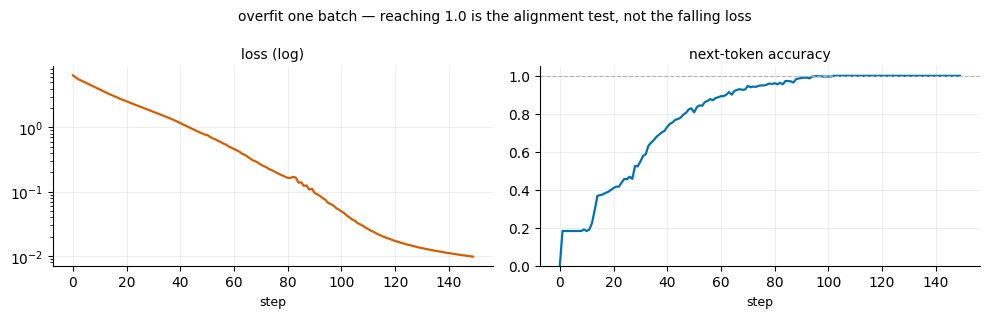

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(hist_loss, color=C_TGT, lw=1.6)
ax[0].set_yscale('log')
ax[0].set_title('loss (log)', fontsize=10)
ax[1].plot(hist_acc, color=C_SRC, lw=1.6)
ax[1].axhline(1.0, color='0.7', lw=0.8, ls='--')
ax[1].set_ylim(0, 1.05)
ax[1].set_title('next-token accuracy', fontsize=10)
for a in ax:
    a.set_xlabel('step', fontsize=9)
    a.grid(alpha=0.25, lw=0.6)
    for s in ('top', 'right'):
        a.spines[s].set_visible(False)
fig.suptitle('overfit one batch — reaching 1.0 is the alignment test, not the falling loss',
    fontsize=10)
fig.tight_layout()
plt.show()

## 8. Free-run generation — encode once, then step the decoder

`generate` differs from the flat form's in one structural way: the source is encoded **once**, and only
the decoder is recomputed per step. The source is the longer half here, so that is most of the work
saved even without a KV cache (the decoder still re-runs its own prefix each step, so this is O(U²) in
the target and is for inspection, not bulk decoding — `tools/midi/translateMidiseq2.py` is the tool for
that).

Two things need care, and both are checked below:

- **`decoder_start_position`** is `<sep>`'s position on the feeder's axis. It defaults to
  `source_position_ids[-1] + 1`, which is right for `pos_style: 'flat'` and **wrong** for `'sep'` /
  `'absolute'`, where `<sep>` sits at `-1` by construction. Passing the wrong one puts every generated
  token on a position the model never saw in training.
- **Indexing.** `val[i]` is the i-th sample *of the split*, whereas `val.describe(...)` takes a
  dataset-wide index — so a readable name needs `val.describe(val.indices[i])`, not `describe(i)`. Easy
  to get wrong and it fails silently by naming the wrong piece.

The output of an untrained model is noise; what is being validated is that the loop runs, respects the
window, stops at `<eos>`, and is greedy-deterministic.

In [16]:
one = val[0]
ids0, sep0, pos0, skip0 = one[0], one[1], one[2], one[3]
# describe() returns the whole item record; its 'name' is the readable part. Note the indexing trap:
# val[i] is the i-th sample OF THE SPLIT, while describe() takes a dataset-wide index.
name = val.describe(val.indices[0])['name']
src0, spos0 = ids0[:sep0].unsqueeze(0), pos0[:sep0].unsqueeze(0)
print('sample     :', name)
print('source len :', int(sep0), '| target len:', int(len(ids0) - sep0 - 1), '| skip:', skip0)
print('pos_style  :', config['data.args.pos_style'], '-> <sep> sits at', int(pos0[sep0]))

START = -1 if config['data.args.pos_style'] in ('sep', 'absolute') else None

def run_gen (**over):
    kw = dict(max_new_tokens=24, source_masks=torch.ones_like(src0),
        source_position_ids=spos0, decoder_start_position=START)
    kw.update(over)
    return model.deducer.generate(src0, **kw)

gen = run_gen()
print('\nreturns a 1-D tensor of ids:', tuple(gen.shape), '(no batch axis, no leading <sep>)')
print('first 16 tokens:')
print('   ' + ' '.join(tok.tokens[int(i)] for i in gen[:16]))
print('leading <sep> not returned :', int(gen[0]) != SEP)
assert gen.dim() == 1
assert int(gen[0]) != SEP

# Greedy must be deterministic; temperature must be able to differ.
print('greedy is deterministic    :', torch.equal(gen, run_gen()))
torch.manual_seed(1)
sampled = run_gen(temperature=1.0)
print('temperature 1.0 differs    :', not torch.equal(gen, sampled), '(sampling, so almost surely)')
assert torch.equal(gen, run_gen())

# Stops at eos_id rather than running to max_new_tokens: force the stop to be the token it emits first.
forced = run_gen(max_new_tokens=200, eos_id=int(gen[0]))
print('stops at eos_id            :', int(forced.numel()) == 1,
      '(%d token before the forced stop, vs max_new_tokens=200)' % forced.numel())
assert int(forced.numel()) == 1 and int(forced[0]) == int(gen[0])

# max_new_tokens is respected when the stop never comes: ask for a token outside the vocab.
capped = run_gen(max_new_tokens=7, eos_id=-1)
print('max_new_tokens respected   :', int(capped.numel()) == 7)
assert int(capped.numel()) == 7

# A batched source is rejected rather than silently decoding row 0.
try:
    model.deducer.generate(src, max_new_tokens=2, source_masks=src_mask)
    raise AssertionError('a batched source must raise')
except ValueError as e:
    print('batched source rejected    :', e)

sample     : 0000d32362fe8ce09e3729147f12996f.midiseq2.txt
source len : 93 | target len: 48 | skip: 0
pos_style  : absolute -> <sep> sits at -1

returns a 1-D tensor of ids: (24,) (no batch axis, no leading <sep>)
first 16 tokens:
   $14 E300 Ea80 Ed20 Ed20 Ed20 Ed20 Ed20 $26 E300 Ed20 Ed20 $26 E300 Ed20 Ed20
leading <sep> not returned : True
greedy is deterministic    : True


temperature 1.0 differs    : True (sampling, so almost surely)
stops at eos_id            : True (1 token before the forced stop, vs max_new_tokens=200)
max_new_tokens respected   : True
batched source rejected    : generate handles one source at a time


## 9. Cross-attention alignment — the thing only this architecture has

The decoder-only arm has no cross-attention, so it has nothing to plot: source and target share one
self-attention map and one position axis. Here the source-to-target correspondence is an explicit
`[B, heads, U, S]` tensor per decoder layer, returned by `decode(..., need_weights=True)`. That is what
`tools/midi/translateMidiseq2.py --inspect` reads for its alignment plots, so its properties are worth
pinning down here.

Three properties, then a picture:

- each query row is a **distribution** over source positions — nonneg, sums to 1;
- masked source positions get **exactly zero** weight, and the mass redistributes over the real ones
  rather than leaking;
- one tensor **per decoder layer**, all the same shape.

The picture uses the *overfit* model from §7 alongside the untrained one, and the honest result is
stated with it: the alignment does **not** sharpen. With teacher forcing, a memorised batch can be
predicted from the decoder's own causal context, so nothing pushes cross-attention to concentrate. What
this section establishes is structural — the tensor is real, per-layer, mask-respecting, and readable by
`--inspect`. It is not evidence about learned alignment, and the plot is labelled accordingly.

In [17]:
model.eval()
with torch.no_grad():
    mem = model.deducer.encode(src, src_mask, src_pos)
    lg, w_all = model.deducer.decode(mem, dec, src_mask, dec_pos, need_weights=True)

print('cross-attention tensors  :', len(w_all), '(one per decoder layer)')
print('each shape               :', tuple(w_all[0].shape), '= [B, heads, U, S]')
print('logits unchanged by need_weights:', torch.allclose(lg, log_b, atol=1e-6))
assert len(w_all) == small['n_layer_decoder']
assert all(tuple(w.shape) == tuple(w_all[0].shape) for w in w_all)

w0 = w_all[0]
row_sums = w0.sum(dim=-1)
pad_mass = torch.stack([w0[r, :, :, int(src_mask[r].sum()):].sum() for r in range(len(src))])
print('\nnonnegative              :', bool((w0 >= 0).all()))
print('rows sum to 1            : max|sum-1| %.3e' % (row_sums - 1).abs().max().item())
print('mass on padded source    : max %.3e  (must be exactly 0)' % pad_mass.max().item())
assert bool((w0 >= 0).all())
assert (row_sums - 1).abs().max().item() < 1e-5
assert pad_mass.max().item() == 0.0

# Mass redistributes rather than vanishing: over the REAL span alone, the row still sums to 1.
r = int(torch.tensor([int(src_mask[i].sum()) for i in range(len(src))]).argmin())
ns = int(src_mask[r].sum())
print('shortest source row %d (%d of %d real): real-span row sums max|sum-1| %.3e'
      % (r, ns, src.shape[1], (w0[r, :, :, :ns].sum(dim=-1) - 1).abs().max().item()))

cross-attention tensors  : 2 (one per decoder layer)
each shape               : (3, 4, 244, 629) = [B, heads, U, S]
logits unchanged by need_weights: True

nonnegative              : True
rows sum to 1            : max|sum-1| 2.384e-07
mass on padded source    : max 0.000e+00  (must be exactly 0)
shortest source row 0 (93 of 629 real): real-span row sums max|sum-1| 2.384e-07


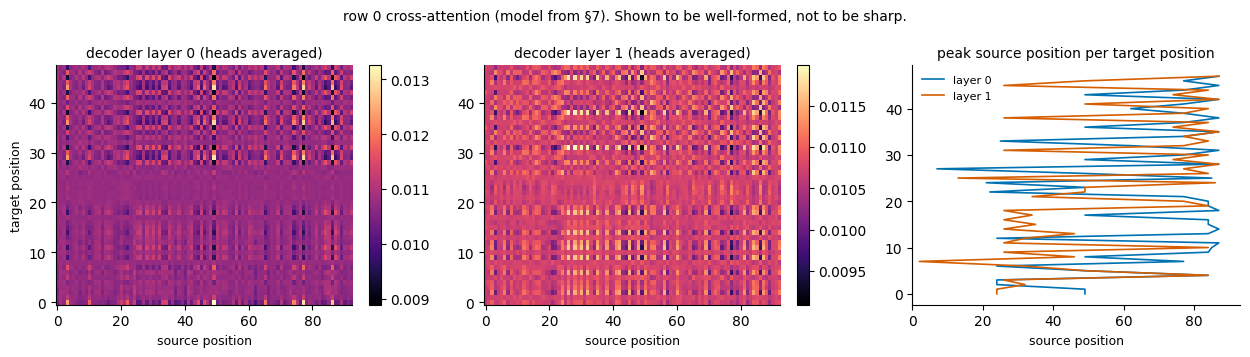

normalised attention entropy, layer 0 (1.0 = uniform over all 93 source positions):
   untrained 1.0000   overfit-on-this-batch 0.9999

Both are ~1.0: the map stays essentially uniform even though §7 drove this batch to accuracy
1.0. That is not a contradiction and not a bug — with teacher forcing the decoder can reach
1.0 from its own causal context alone on a memorised batch, so nothing forces cross-attention
to sharpen. The claim this section supports is only the structural one: the tensor is
per-layer, mask-respecting, and shaped for --inspect to read. Whether attention becomes
interpretable is a question for a real training run, not for this notebook.


In [18]:
fit.eval()
r = 0
ns, nd = int(src_mask[r].sum()), int(tmask[r].sum())
with torch.no_grad():
    mem_f = fit.deducer.encode(src, src_mask, src_pos)
    _, w_fit = fit.deducer.decode(mem_f, dec, src_mask, dec_pos, need_weights=True)

n_layer = len(w_fit)
fig, axes = plt.subplots(1, n_layer + 1, figsize=(4.2 * (n_layer + 1), 3.6))
for li in range(n_layer):
    m = w_fit[li][r, :, :nd, :ns].mean(dim=0)       # head-averaged
    im = axes[li].imshow(m.numpy(), aspect='auto', origin='lower', cmap='magma')
    axes[li].set_title('decoder layer %d (heads averaged)' % li, fontsize=10)
    axes[li].set_xlabel('source position', fontsize=9)
    axes[li].set_ylabel('target position' if li == 0 else '', fontsize=9)
    fig.colorbar(im, ax=axes[li], fraction=0.046)

# Where each target position looks, per layer: argmax over the source. A diagonal would mean monotone
# alignment. Do not expect one here — see the entropy numbers printed below.
for li in range(n_layer):
    peak = w_fit[li][r, :, :nd, :ns].mean(dim=0).argmax(dim=-1).numpy()
    axes[-1].plot(peak, np.arange(nd), lw=1.2, label='layer %d' % li,
        color=[C_SRC, C_TGT, '#009E73', '#CC79A7'][li % 4])
axes[-1].set_title('peak source position per target position', fontsize=10)
axes[-1].set_xlabel('source position', fontsize=9)
axes[-1].set_xlim(0, ns)
axes[-1].legend(fontsize=8, frameon=False)
for a in axes:
    for s in ('top', 'right'):
        a.spines[s].set_visible(False)
fig.suptitle('row %d cross-attention (model from §7). Shown to be well-formed, not to be sharp.' % r,
    fontsize=10)
fig.tight_layout()
plt.show()

untrained = w_all[0][r, :, :nd, :ns].mean(dim=0)
overfit = w_fit[0][r, :, :nd, :ns].mean(dim=0)
def entropy (m):
    return float((-(m.clamp_min(1e-12).log() * m).sum(dim=-1) / np.log(ns)).mean())
e_un, e_fit = entropy(untrained), entropy(overfit)
print('normalised attention entropy, layer 0 (1.0 = uniform over all %d source positions):' % ns)
print('   untrained %.4f   overfit-on-this-batch %.4f' % (e_un, e_fit))
print()
print('Both are ~1.0: the map stays essentially uniform even though §7 drove this batch to accuracy')
print('1.0. That is not a contradiction and not a bug — with teacher forcing the decoder can reach')
print('1.0 from its own causal context alone on a memorised batch, so nothing forces cross-attention')
print('to sharpen. The claim this section supports is only the structural one: the tensor is')
print('per-layer, mask-respecting, and shaped for --inspect to read. Whether attention becomes')
print('interpretable is a question for a real training run, not for this notebook.')

## What this validates, and what it does not

**Validated here**

- The `pack: 'split'` batch has the geometry the model expects: eight tensors, `<sep>` first in every
  decoder row, labels equal to the decoder input shifted left, `target_mask` a subset of `decoder_masks`.
- **Label-set parity with `pack: 'flat'`** over identical crops, element-for-element and per-row, with
  and without `start_jitter` — so the encoder-decoder run and the decoder-only run are supervised on
  exactly the same tokens, and a difference between them is attributable to the architecture (§2b).
- The two position axes rejoin the flat form's single axis; `<sep>` anchors the decoder at `-1` under
  `sep`/`absolute`; pad tails continue each row's run; RoPE makes `flat` and `sep` equivalent at the
  encoder output while `absolute` genuinely differs (§2c).
- Exactly one shift is applied, and it is the collate's — `_shift` returns logits rows `[0, 1, 2]` where
  the flat form returns `[2, 3, 4]` (§3).
- All three attention paths behave as specified, recovered from the model by perturbation rather than
  read off the mask builders: the encoder is **bidirectional**, the decoder is causal, cross-attention is
  non-causal in both axes (§4a). The decoder's omitted key-padding mask is shown to be redundant over
  what `target_mask` keeps — bit-identical logits on the real positions — and the classic all-`-inf`/`nan`
  hazard is shown *not* to apply here, swept over all 32 key-padding layouts of a row (§4).
- Padding changes no number, on the encoder output and the logits independently; the batch loss equals
  the token-weighted mean of per-row losses (§5).
- Three overrides, seven inherited members identity-checked against the parent, `stat()` folding,
  per-type CE weights, the typo guard, and the checkpoint contract (§6).
- One batch is driven to accuracy 1.0, which an off-by-one or an unreachable source cannot do (§7).
- `generate` encodes once, is greedy-deterministic, stops at `<eos>`, and rejects a batched source (§8).
- Cross-attention weights are per-layer, mask-respecting distributions over the source, shaped for
  `--inspect` to read (§9).

**Not validated here**

- **Any claim about quality.** Nothing in this notebook says the encoder-decoder arm translates better
  than the decoder-only one. That needs the two configs trained on the same corpus to convergence and
  compared on held-out data; this notebook only establishes that a difference between them would be
  attributable to the architecture rather than to a batching or metric discrepancy.
- **Real-scale behaviour.** Everything runs at `d_model=128`, two layers per stack, on CPU, over a
  three-sample batch from the test corpus. Memory, throughput, and optimisation dynamics at
  `d_model=512` / e4d4 / production sequence lengths are not exercised. In particular the
  non-SDPA cross-attention materialises `[B, heads, U, S]`, which is the measured reason this arm's step
  is slower than the flat one's at equal batch size — that cost is not visible at this scale.
- **Learned alignment.** §9 shows the cross-attention tensor is well-formed and readable by
  `--inspect`. It shows the opposite of sharpening: even overfit to accuracy 1.0, the map stays
  essentially uniform, because teacher forcing lets the decoder memorise a batch from its own causal
  context. Whether cross-attention becomes interpretable is a question for a real training run.
- **Sliding-window inference.** `tools/midi/translateMidiseq2.py` has its own window/prime geometry and
  its own checks; nothing here covers it.